<a href="https://colab.research.google.com/github/pyingqi18/ECON5314G/blob/main/CASI_chapter_1_algorithm%26inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 Algorithms and Inference

This notebook separates the **algorithm** (how an estimate is computed) from **inference** (how its uncertainty is assessed). We compare linear regression with LOWESS and use the bootstrap when a simple standard-error formula is unavailable.

**Tools used.** [statsmodels](https://www.statsmodels.org/dev/about.html#about-statsmodels) fits OLS and LOWESS models. Matplotlib's [LineCollection](https://matplotlib.org/stable/gallery/shapes_and_collections/line_collection.html) efficiently draws the repeated uncertainty bars used in the book's figures.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from matplotlib.collections import LineCollection

## 1.1 A Regression Example

### 1.1.1 Data

The data contain $n=157$ healthy volunteers. For volunteer $i$, $x_i$ is age in years and $y_i$ is `tot`, a composite measure of overall kidney function. The goal is to describe how expected `tot` changes with age and to quantify uncertainty in that relationship.

##### Data loading

In [ ]:
kidney = pd.read_csv("kidney.txt", delimiter=" ")

##### Data viewing

In [ ]:
# kidney
# kidney.head()
kidney.tail()

,age,tot
152,73,-0.33
153,74,-5.73
154,80,-5.14
155,82,-2.08
156,88,-4.86


##### Data plotting

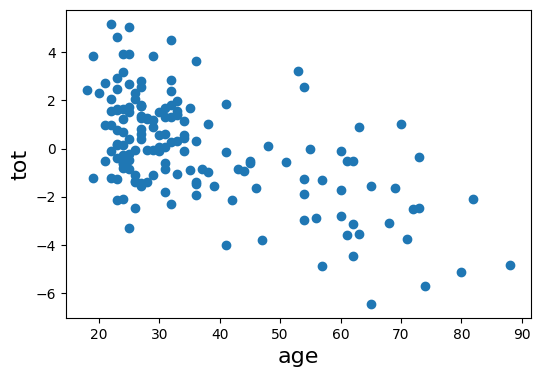

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))  # fig creates a canvas, 'ax' creates an empty figure (for now)

# ax.scatter(kidney.age, kidney.tot)  # scatter() plots scatter plots
ax.plot(kidney.age, kidney.tot, "o")
ax.set_xlabel("age", size=16);  # set_xlable() sets x-label
ax.set_ylabel("tot", size=16);  # set_ylable() sets y-label

plt.show()

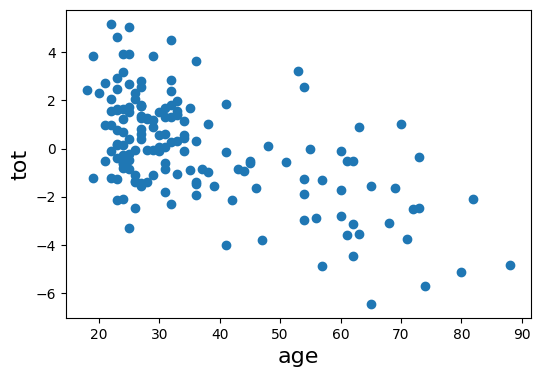

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
x = kidney.age
y = kidney.tot
ax.plot(x, y, "o")
ax.set_xlabel("age", size=16)
ax.set_ylabel("tot", size=16)
plt.show()

### 1.1.2 Linear Regression with OLS (ordinary least squares)

The model `tot ~ age` represents a straight-line mean relationship. OLS chooses the intercept and slope that minimize the sum of squared residuals; inference then asks how precisely that fitted line has been estimated.

##### Fit the model by OLS

In [8]:
model = sm.formula.ols(formula = "tot ~ age", data = kidney)  # in sm.formula.ols(), 'y ~ x' means run ols on y = beta*x + e
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    tot   R-squared:                       0.327
Model:                            OLS   Adj. R-squared:                  0.323
Method:                 Least Squares   F-statistic:                     75.31
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           5.18e-15
Time:                        00:00:31   Log-Likelihood:                -314.14
No. Observations:                 157   AIC:                             632.3
Df Residuals:                     155   BIC:                             638.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.8600      0.360      7.954      0.0

In [ ]:
# print(results.summary())
# print("Parameters: ", results.params)
# print("R2: ", results.rsquared)
# print("Predicted values: ", results.predict())

##### Predictions and uncertainty with `get_prediction()`

`summary_frame()` reports both uncertainty for the **mean response** at each age and a wider **prediction interval** for a new individual. These answer different questions and should not be interpreted interchangeably.

In [9]:
xline = pd.DataFrame({"age": range(20, 90, 10)})
xline

,age
0,20
1,30
2,40
3,50
4,60
5,70
6,80


In [10]:
xline = pd.DataFrame({"age": range(20, 90, 10)})
pred = results.get_prediction(xline)
pred_info = pred.summary_frame()
pred_info.index = xline.age
pred_info
# pred_info['obs_ci_lower']
# pred_info['obs_ci_upper']

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
age,,,,,,
20,1.288258,0.206648,0.880048,1.696469,-2.292802,4.869319
30,0.502374,0.154965,0.196259,0.808490,-3.068490,4.073238
40,-0.283510,0.147398,-0.574678,0.007659,-3.853123,3.286104
50,-1.069394,0.189314,-1.443363,-0.695425,-4.646713,2.507926
60,-1.855278,0.257595,-2.364127,-1.346429,-5.449202,1.738646
70,-2.641162,0.336559,-3.305996,-1.976329,-6.260467,0.978142
80,-3.427046,0.420226,-4.257155,-2.596937,-7.080325,0.226232


##### Plot the fitted line and prediction interval

The dashed bounds below are observation-level prediction limits, so they include both uncertainty in the fitted mean and person-to-person variation around the line.

In [11]:
pred_ols = results.get_prediction()
iv_l = pred_ols.summary_frame()["obs_ci_lower"]
iv_u = pred_ols.summary_frame()["obs_ci_upper"]
x = kidney.age
y = kidney.tot

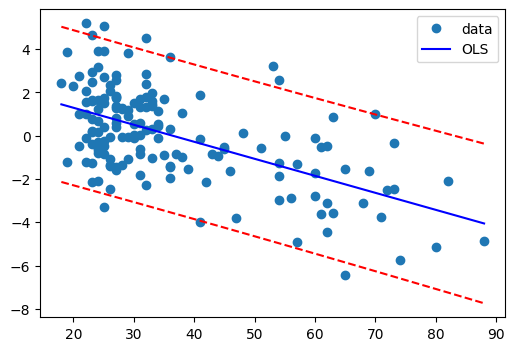

In [12]:
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(x, y, "o", label="data")
ax.plot(x, results.fittedvalues, "b-", label="OLS")
ax.plot(x, iv_u, "r--")
ax.plot(x, iv_l, "r--")
ax.legend(loc="best")

plt.show()

##### Replicate CASI Figure 1.1

The vertical segments are approximately $Â±2$ standard errors for the fitted **mean** at selected ages. They are narrower than prediction intervals because they do not include individual residual variation.

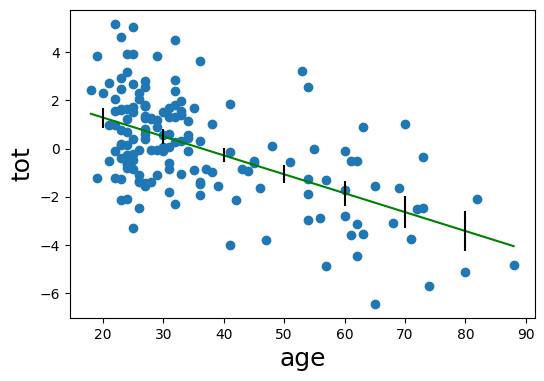

In [13]:
se_lines = LineCollection([[[age, pred - 2 * se], [age, pred + 2 * se]]
                           for age, pred, se in zip(pred_info.index, pred_info["mean"], pred_info["mean_se"])], color="k")

fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(kidney.age, kidney.tot)
ax.plot(x, results.fittedvalues, "g-", label="OLS")
ax.add_collection(se_lines)
ax.set_xlabel("age", size=18)
ax.set_ylabel("tot", size=18)

plt.show()

### 1.1.3 LOWESS

LOWESS replaces the single global line with local weighted regressions. This flexibility can reveal curvature, but its uncertainty is less convenient to derive analytically, which motivates the bootstrap.

##### Import packages

In [14]:
from statsmodels.nonparametric.smoothers_lowess import lowess

##### Fit the main LOWESS curve

The smoothing fraction `frac=1/3` means each local fit uses roughly one third of the observations. Smaller values follow the data more closely; larger values produce a smoother curve. The [lowess](https://www.statsmodels.org/dev/generated/statsmodels.nonparametric.smoothers_lowess.lowess.html) function returns a two-column NumPy array containing sorted ages and fitted values.

In [17]:
low_preds = lowess(kidney.tot, kidney.age, frac=1/3) #越小越粗糙的filtering
#low_preds = lowess(kidney.tot, kidney.age, frac=1/10)
low_preds[:5]

array([[18.        ,  2.24792193],
       [19.        ,  1.95243881],
       [19.        ,  1.95243881],
       [20.        ,  1.65762652],
       [21.        ,  1.36364605]])

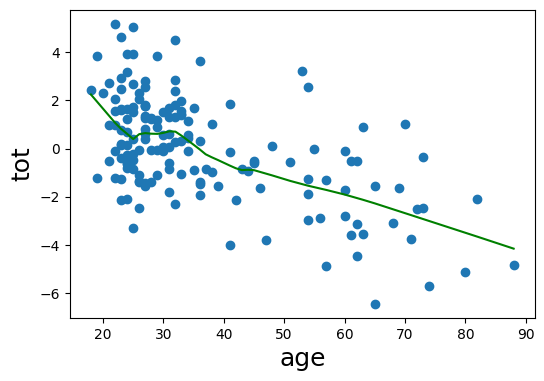

In [18]:
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(kidney.age, kidney.tot)
ax.plot(low_preds[:, 0], low_preds[:, 1], color="g")
ax.set_xlabel("age", size=18)
ax.set_ylabel("tot", size=18)
plt.show()

##### Estimate LOWESS uncertainty by bootstrapping

Each bootstrap iteration resamples the observed `(age, tot)` pairs with replacement and refits the entire smoother. The variation among refitted curves approximates the sampling variability of the LOWESS algorithm.

In [20]:
bootdata = kidney.sample(n=157, replace=True)
bootdata

,age,tot
40,25,-3.30
113,41,1.87
17,23,-1.28
60,27,-1.44
132,57,-1.31
...,...,...
79,31,-0.84
14,23,1.62
137,61,-3.60
12,22,5.19


In [22]:
new_preds = lowess(bootdata.tot, bootdata.age, frac=1/3)
new_preds

array([[ 1.80000000e+01,  2.58597797e+00],
       [ 1.90000000e+01,  2.18456078e+00],
       [ 1.90000000e+01,  2.18456078e+00],
       [ 1.90000000e+01,  2.18456078e+00],
       [ 2.00000000e+01,  1.80278793e+00],
       [ 2.10000000e+01,  1.42352502e+00],
       [ 2.10000000e+01,  1.42352502e+00],
       [ 2.10000000e+01,  1.42352502e+00],
       [ 2.10000000e+01,  1.42352502e+00],
       [ 2.20000000e+01,  9.91469013e-01],
       [ 2.20000000e+01,  9.91469013e-01],
       [ 2.20000000e+01,  9.91469013e-01],
       [ 2.20000000e+01,  9.91469013e-01],
       [ 2.20000000e+01,  9.91469013e-01],
       [ 2.20000000e+01,  9.91469013e-01],
       [ 2.30000000e+01,  6.85575473e-01],
       [ 2.30000000e+01,  6.85575473e-01],
       [ 2.30000000e+01,  6.85575473e-01],
       [ 2.30000000e+01,  6.85575473e-01],
       [ 2.30000000e+01,  6.85575473e-01],
       [ 2.30000000e+01,  6.85575473e-01],
       [ 2.30000000e+01,  6.85575473e-01],
       [ 2.30000000e+01,  6.85575473e-01],
       [ 2.

In [21]:
B = 1000

low_boots = []
for i in range(B):
    boot_data = kidney.sample(n=157, replace=True)
    new_preds = lowess(boot_data.tot, boot_data.age, frac=1/3)
    low_boots.append(new_preds)

# new_preds

##### Convert bootstrap curves to pointwise standard errors

Every refitted curve is evaluated on the same age grid, 20 through 80. Interpolation is necessary because a resample may omit an age or contain it multiple times. At each grid point, the standard deviation across bootstrap fits estimates the pointwise standard error.

In [ ]:
from scipy.interpolate import interp1d

In [ ]:
# interpolate lowess predictions for age = 20, 30, ..., 80
xline = np.array(list(range(20, 90, 10)))
dec_preds = np.zeros((7, 1000))
for i, pred in enumerate(low_boots):
    # interp1d seems to have trouble with non-unique values
    pred = np.unique(pred, axis=0)
    # create an interpolator and collect each lowess's predictions
    interpolate = interp1d(pred[:, 0], pred[:, 1], fill_value="extrapolate", assume_sorted=True)
    dec_preds[:, i] = interpolate(xline)

# get standard deviation for each age
var = np.var(dec_preds, axis=1, ddof=1)
sds = np.sqrt(var)

Collect info for standard error lines

In [ ]:
# interpolate/predict from the original lowess predictions
interpolate = interp1d(low_preds[:, 0], low_preds[:, 1], fill_value="extrapolate", assume_sorted=True)

se_lines = LineCollection(
    [
        [[age, interpolate(age) - 2 * se], [age, interpolate(age) + 2 * se]]
        for age, se in zip(xline, sds)
    ],
    color="k")

##### replicate Figure 1.2

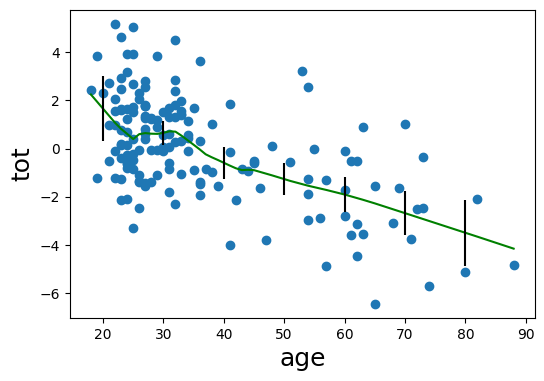

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(kidney.age, kidney.tot)
ax.plot(low_preds[:, 0], low_preds[:, 1], color="g")
ax.add_collection(se_lines)
ax.set_xlabel("age", size=18)
ax.set_ylabel("tot", size=18)
plt.show()

##### replicate Table 1.1

In [ ]:
tmplt = " {:>5.2f} {:>5.2f} {:>5.2f} {:>5.2f} {:>5.2f} {:>5.2f} {:>5.2f}"
print("                                           age")
print("                        -----------------------------------------")
print("                          20    30    40    50    60    70    80")
print("-" * 65)
print(" 1. linear regression " + tmplt.format(*pred_info["mean"]))
print(" 2. std error         " + tmplt.format(*pred_info["mean_se"]))
print()
print(" 3. lowess            " + tmplt.format(*interpolate(xline)))
print(" 4. bootstrap std error" + tmplt.format(*sds))

                                           age
                        -----------------------------------------
                          20    30    40    50    60    70    80
-----------------------------------------------------------------
 1. linear regression   1.29  0.50 -0.28 -1.07 -1.86 -2.64 -3.43
 2. std error           0.21  0.15  0.15  0.19  0.26  0.34  0.42

 3. lowess              1.66  0.65 -0.59 -1.27 -1.91 -2.68 -3.50
 4. bootstrap std error  0.67  0.25  0.33  0.33  0.35  0.46  0.69


The bootstrap standard errors should be close to the book's values but need not match exactly. With $B=1000$ resamples, some Monte Carlo variation remains, and implementation details such as interpolation can also create small differences.

##### Replicate Figure 1.3

Overlaying the bootstrap curves makes uncertainty visible: tight bundles indicate stable fitted values, while greater vertical spread indicates ages where the LOWESS estimate is less precise.

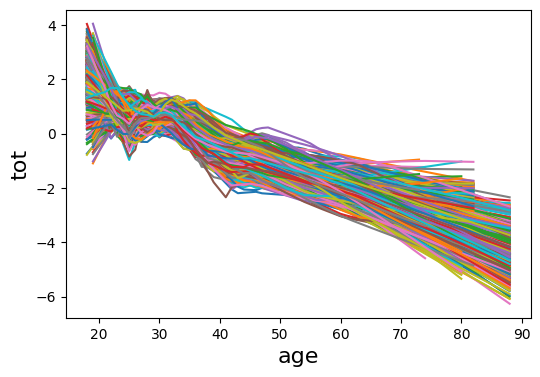

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))

for preds in low_boots[:1000]:
    ax.plot(preds[:, 0], preds[:, 1])

ax.set_xlabel("age", size = 16)
ax.set_ylabel("tot", size = 16)
plt.show()